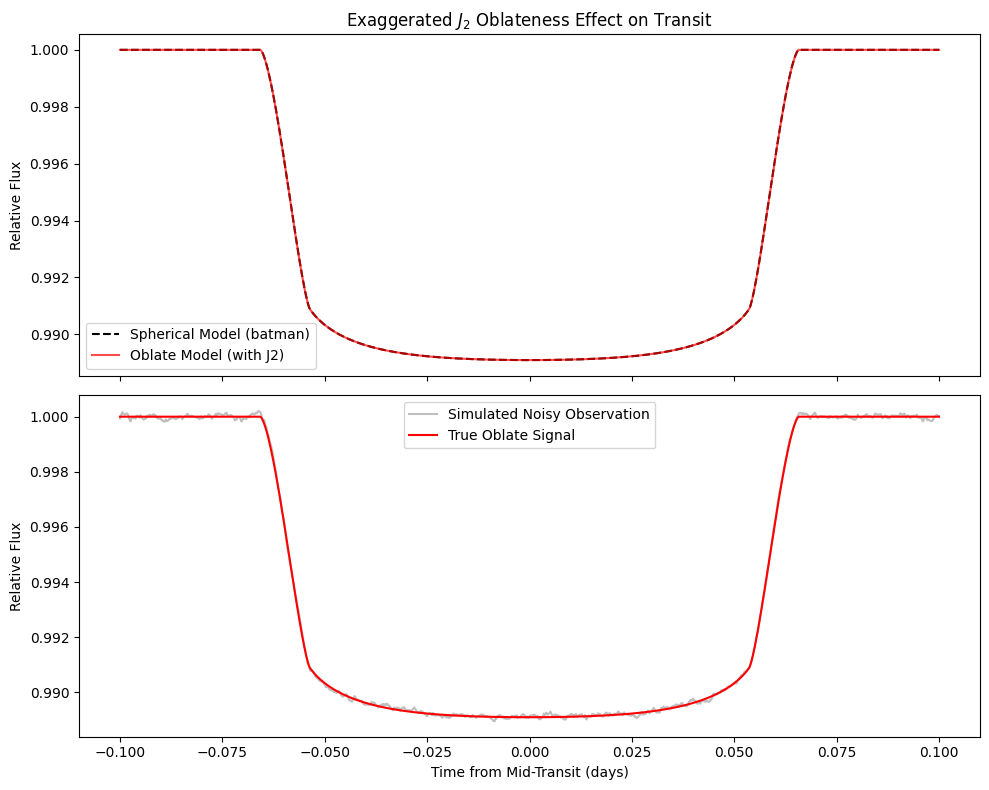

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..') # Allow notebook to see the src folder

from src.components.data_simulator import TransitSimulator

# 1. Setup the time array (e.g., a phase-folded transit window of 4 hours)
time = np.linspace(-0.1, 0.1, 1000) 

# 2. Initialize the simulator
sim = TransitSimulator(time)

# 3. Generate a massive J2 signal (exaggerated for visualization)
clean, oblate, noisy = sim.generate_lightcurve(
    rp_rs=0.1,   # Jupiter-sized planet around Sun-like star
    period=3.0,  # 3 day orbit
    a_rs=8.0, 
    inc=89.5, 
    j2=0.05,     # Highly exaggerated J2 value!
    noise_level=200e-6 
)

# 4. Plot the comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top panel: The clean signals
ax1.plot(time, clean, label='Spherical Model (batman)', color='black', linestyle='--')
ax1.plot(time, oblate, label='Oblate Model (with J2)', color='red', alpha=0.7)
ax1.set_ylabel('Relative Flux')
ax1.set_title('Exaggerated $J_2$ Oblateness Effect on Transit')
ax1.legend()

# Bottom panel: What the CNN will actually see
ax2.plot(time, noisy, label='Simulated Noisy Observation', color='gray', alpha=0.5)
ax2.plot(time, oblate, label='True Oblate Signal', color='red')
ax2.set_xlabel('Time from Mid-Transit (days)')
ax2.set_ylabel('Relative Flux')
ax2.legend()

plt.tight_layout()
plt.show()

In [2]:
import os

# 1. Generate 10,000 samples (This will take a minute or two)
X_data, y_data = sim.generate_dataset(num_samples=10000, noise_level=150e-6)

# 2. Split into Training and Testing sets (80/20 split)
split_idx = int(0.8 * len(X_data))

X_train, X_test = X_data[:split_idx], X_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

# 3. Save to your data/synthetic/ folder
save_dir = "../data/synthetic"

np.save(os.path.join(save_dir, "X_train.npy"), X_train)
np.save(os.path.join(save_dir, "X_test.npy"), X_test)
np.save(os.path.join(save_dir, "y_train.npy"), y_train)
np.save(os.path.join(save_dir, "y_test.npy"), y_test)

print(f"Dataset successfully saved to {save_dir}!")
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")


Generating 10000 synthetic light curves...


100%|██████████| 10000/10000 [00:12<00:00, 792.32it/s]


Dataset successfully saved to ../data/synthetic!
Training shapes: X=(8000, 1000), y=(8000,)
